<a href="https://colab.research.google.com/github/Blenkzx/LINGUAGENS-DE-PROGRAMA-O/blob/main/AtivPr%C3%A1ticaSeaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)

## Parte 1: Distribuições e Contagens (Básico)


/tmp/ipykernel_10449/400458621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sistema, x='plano', order=df_sistema['plano'].value_counts().index, palette='viridis')


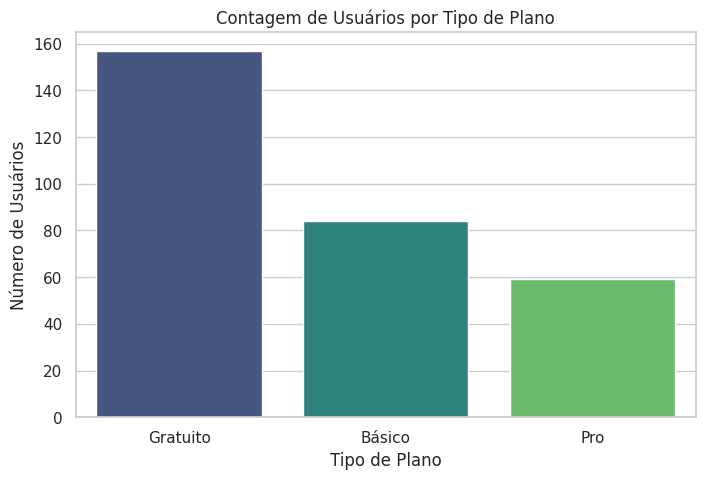

In [2]:
# 1. Gráfico de barras para contagem de usuários por tipo de plano
plt.figure(figsize=(8, 5))
sns.countplot(data=df_sistema, x='plano', order=df_sistema['plano'].value_counts().index, palette='viridis')
plt.title('Contagem de Usuários por Tipo de Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Número de Usuários')
plt.show()

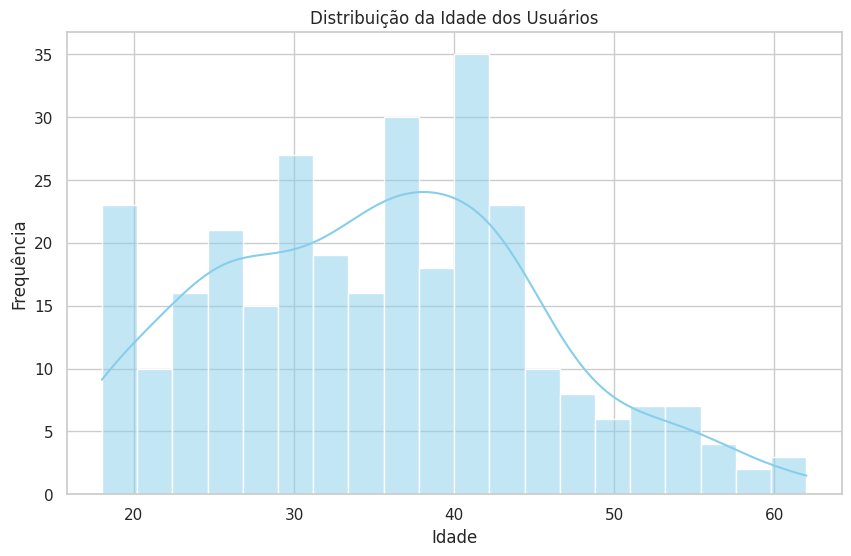

In [3]:
# 2. Distribuição da idade com histplot e KDE
plt.figure(figsize=(10, 6))
sns.histplot(df_sistema['idade'], kde=True, bins=20, color='skyblue')
plt.title('Distribuição da Idade dos Usuários')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

## Parte 2: Relações Categóricas e Numéricas (Intermediário)


/tmp/ipykernel_10449/227421695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sistema, x='plano', y='tempo_uso_horas', palette='magma')


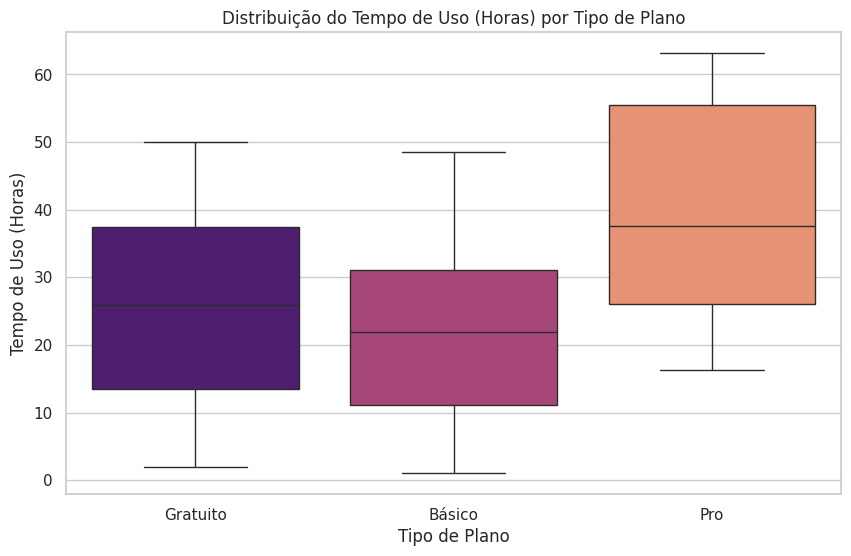

In [4]:
# 3. Boxplot para tempo_uso_horas por tipo de plano
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sistema, x='plano', y='tempo_uso_horas', palette='magma')
plt.title('Distribuição do Tempo de Uso (Horas) por Tipo de Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Tempo de Uso (Horas)')
plt.show()

/tmp/ipykernel_10449/1675933321.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_sistema, x='plano', y='satisfacao', palette='plasma')


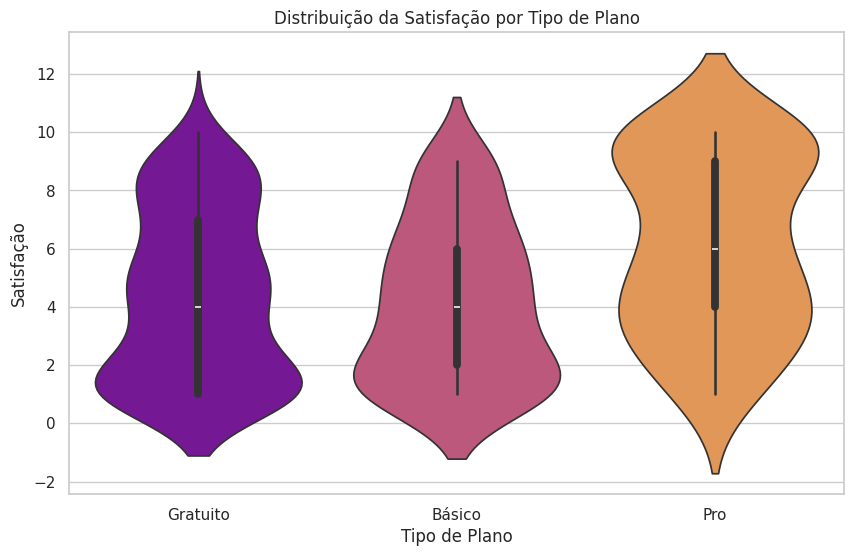

In [5]:
# 4. Violinplot para satisfacao por tipo de plano
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_sistema, x='plano', y='satisfacao', palette='plasma')
plt.title('Distribuição da Satisfação por Tipo de Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Satisfação')
plt.show()

## Parte 3: Correlações e Análise Multivariada (Avançado)


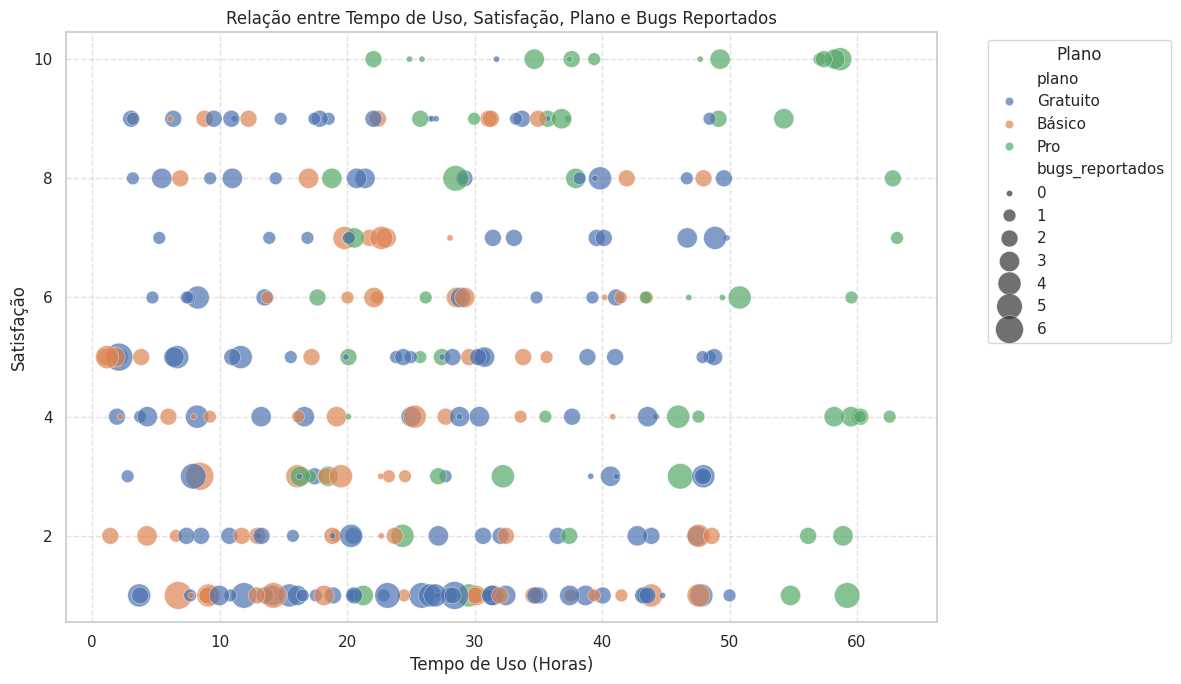

In [6]:
# 5. Scatterplot: tempo_uso_horas vs. satisfacao, com hue por plano e size por bugs_reportados
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_sistema, x='tempo_uso_horas', y='satisfacao', hue='plano', size='bugs_reportados', sizes=(20, 400), palette='deep', alpha=0.7)
plt.title('Relação entre Tempo de Uso, Satisfação, Plano e Bugs Reportados')
plt.xlabel('Tempo de Uso (Horas)')
plt.ylabel('Satisfação')
plt.legend(title='Plano', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

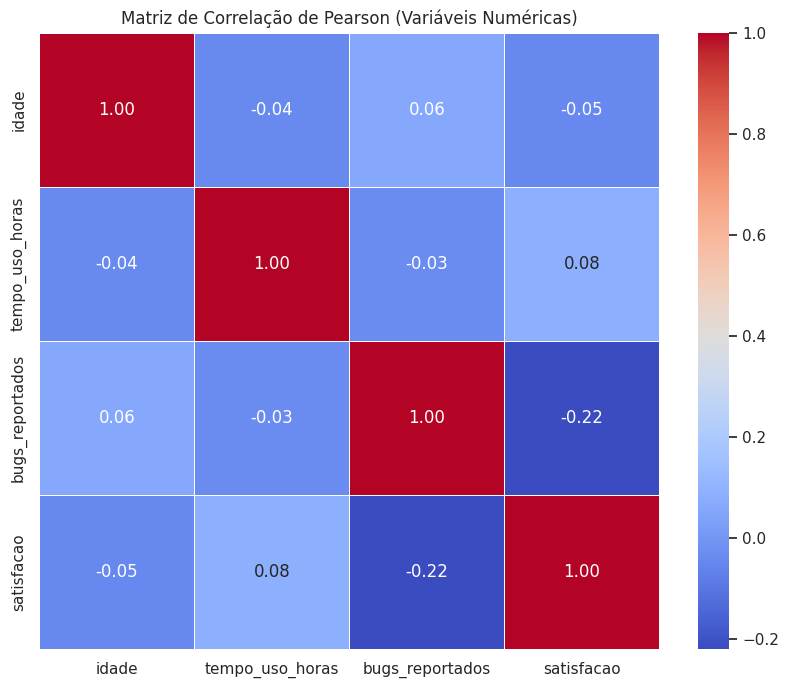

In [7]:
# 6. Matriz de correlação de Pearson para variáveis numéricas e heatmap
# Selecionando apenas as colunas numéricas
df_numerico = df_sistema.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(df_numerico.corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação de Pearson (Variáveis Numéricas)')
plt.show()

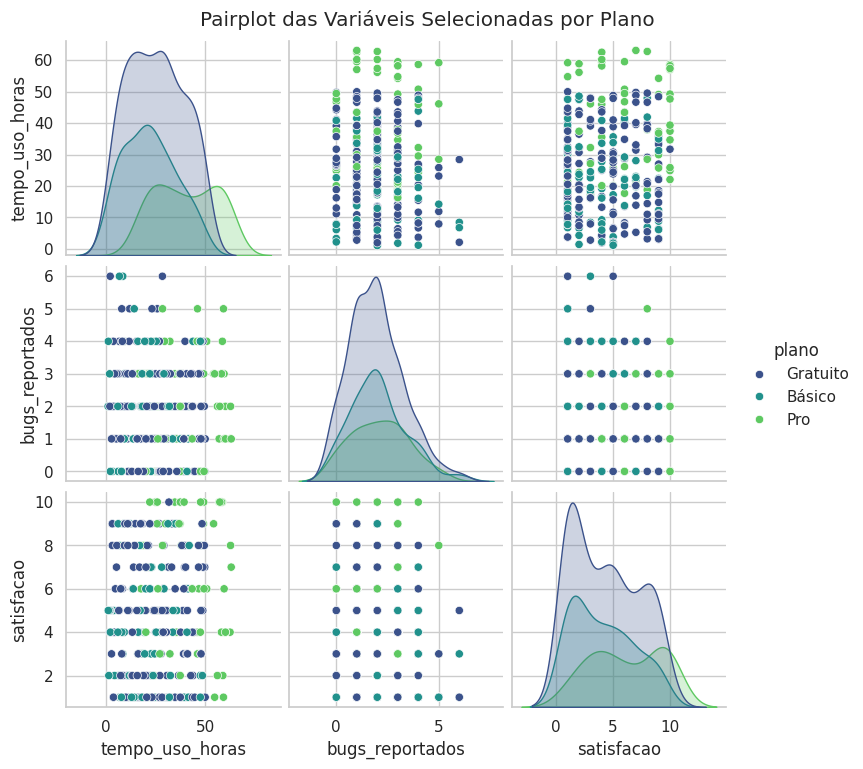

In [8]:
# 7. (Bônus) Pairplot com tempo_uso_horas, bugs_reportados e satisfacao, com hue por plano
sns.pairplot(df_sistema, vars=['tempo_uso_horas', 'bugs_reportados', 'satisfacao'], hue='plano', palette='viridis')
plt.suptitle('Pairplot das Variáveis Selecionadas por Plano', y=1.02) # Ajusta o título para não sobrepor
plt.show()